# Day 209 — Week 3, Day 2: QLoRA Training Run (4-bit Quant, Real Dataset)
### Month 13 — Agentic AI & Advanced GenAI Portfolio

**Builds on:** Day 208 (LoRA/QLoRA fundamentals + PEFT setup, verified param counts: 740,355 trainable / 67,696,134 total = 1.0936%)

**Today's scenario:** TeleServe India support-ticket **priority classification** (P1 = critical, P2 = moderate, P3 = low), 450 real-format tickets (seed=209). Day 208 built the LoRA-wrapped model and proved the math on paper. Today you actually **train it** — real forward/backward passes, real loss curve, real before/after accuracy — using the QLoRA setup (4-bit base + LoRA adapters).

**Stack:** `transformers==5.13.1`, `peft==0.19.1`, `bitsandbytes` (4-bit, Colab T4 GPU only), `torch`, `scikit-learn`

---
### File Structure (per program convention)
1. **Raw Data** (locked, never modified) — `teleserve_tickets_209.csv`
2. **Practice Guide** — 6 tasks below, each with TODOs
3. **Concept Notes** — inline in each task's markdown
4. **Answer Key** — final section, exact verified numbers
5. **Scoring Rubric** — final section, points per task

---
### ⚠️ Colab T4 requirement for Task 3 only
Task 3 (loading the base model in real 4-bit via `bitsandbytes`) **requires a CUDA GPU**. It will not run on CPU — `bitsandbytes` 4-bit kernels are GPU-only. Everything else in this notebook (data, LoRA wrapping, training loop, evaluation) was verified end-to-end in this environment on CPU using fp32, so the *training mechanics* are proven; Task 3's actual 4-bit memory numbers must come from your live Colab T4 run, same convention as Day 208's memory-footprint math.


In [1]:
# ── SETUP: Install dependencies and import libraries ──────────────────
# Goal: Set up the environment for QLoRA training on TeleServe ticket data.
# Method: Install required packages (transformers, peft, bitsandbytes, etc.),
#         upgrade torchao to avoid version conflict, import all modules.

!pip install -q transformers==5.13.1 peft==0.19.1 bitsandbytes accelerate scikit-learn --upgrade
!pip install -q --upgrade torchao   # Fixes ImportError: incompatible torchao version

import torch
import numpy as np
import pandas as pd
import time
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(209)
np.random.seed(209)

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.4 MB/s eta 0:00:00


torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## Section 1 — Raw Data (LOCKED — never modify)
`teleserve_tickets_209.csv`: 450 TeleServe India support tickets, seed=209, perfectly balanced (150 P1 / 150 P2 / 150 P3). Columns: `ticket_id`, `category`, `text`, `priority`.

Do not edit this file or the DataFrame loaded from it. All splitting/encoding happens on copies.

In [3]:
# Load locked raw data — DO NOT MODIFY
raw_df = pd.read_csv("teleserve_tickets_209.csv")
print("Raw shape:", raw_df.shape)
print(raw_df['priority'].value_counts())
raw_df.head(3)


Raw shape: (450, 4)
priority
P1    150
P2    150
P3    150
Name: count, dtype: int64


,ticket_id,category,text,priority
0,TSI-209-0013,Roaming,"SIM swapped without my consent, OTPs being rec...",P1
1,TSI-209-0266,Data Plan,Billing dispute: charged for Postpaid Infinity...,P2
2,TSI-209-0088,Roaming,Unauthorized transaction of Rs.499 detected on...,P1


## Task 1 — Stratified Train/Val Split + Tokenization (15 pts)

**Concept:** With only 450 rows and 3 classes, a plain random split can accidentally skew class balance in the validation set, which would make your before/after accuracy numbers meaningless (you'd be comparing against a lucky or unlucky val set, not a fair one). `stratify=` on `train_test_split` forces every split to preserve the original class proportions.

**TODO:**
1. Map `priority` → `label` (P1=0, P2=1, P3=2)
2. `train_test_split(test_size=0.2, stratify=labels, random_state=209)`
3. Tokenize both splits with `AutoTokenizer.from_pretrained("distilbert-base-uncased")`, `max_length=64`, `padding=True`, `truncation=True`
4. Print train/val shapes and confirm class balance is preserved in both splits (print `value_counts()` for each)


In [4]:
# ── TASK 1 (15 pts): Train/val split and tokenization ────────────────
# Goal: Split data with class balance preserved, tokenize for DistilBERT.
# Method: Map labels to ids, use train_test_split with stratify, tokenize.

label2id = {"P1": 0, "P2": 1, "P3": 2}
id2label = {v: k for k, v in label2id.items()}

df = raw_df.copy()
df["label"] = df["priority"].map(label2id)

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=209
)

print("train shape:", train_df.shape)
print("val shape:", val_df.shape)
print("\ntrain class balance:\n", train_df["priority"].value_counts())
print("\nval class balance:\n", val_df["priority"].value_counts())

model_name = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)

def encode(texts):
    return tok(list(texts), truncation=True, padding=True, max_length=64, return_tensors="pt")

train_enc = encode(train_df["text"])
val_enc = encode(val_df["text"])
print("\ntrain input_ids shape:", train_enc["input_ids"].shape)
print("val input_ids shape:", val_enc["input_ids"].shape)

train shape: (360, 5)
val shape: (90, 5)

train class balance:
 priority
P2    120
P3    120
P1    120
Name: count, dtype: int64

val class balance:
 priority
P2    30
P1    30
P3    30
Name: count, dtype: int64


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


train input_ids shape: torch.Size([360, 32])
val input_ids shape: torch.Size([90, 31])


## Task 2 — Rebuild the Day 208 LoRA Model + BEFORE-Training Baseline (20 pts)

**Concept:** Before training, `lora_B` is zero-initialized (Day 208 proved this via gradient check: `lora_A.grad != 0`, `lora_B.grad == 0` at step 0), so the LoRA adapters contribute nothing (`ΔW = BA = 0`). But `pre_classifier`/`classifier` are `modules_to_save` — freshly initialized, fully trainable, and **not** zero at init. So the "before training" prediction isn't the pretrained DistilBERT's opinion; it's whatever random weights the new classification head started with. For 3 balanced classes, random-head predictions should land close to chance (~33%).

**TODO:**
1. Load `distilbert-base-uncased` with `num_labels=3`, `id2label`, `label2id`
2. Apply the exact Day 208 LoRA config: `r=8, lora_alpha=16, lora_dropout=0.1, target_modules=["q_lin","v_lin"], task_type=SEQ_CLS`
3. Print trainable/total params — confirm it matches Day 208's `740,355` trainable exactly
4. Run inference on the val set with **zero training** and compute accuracy — this is your BEFORE baseline


In [5]:
# ── TASK 2 (20 pts): LoRA model and before-training accuracy ─────────
# Goal: Build the exact LoRA model from Day 208, verify trainable count,
#       and compute validation accuracy BEFORE any training.
# Method: Load base model, apply LoraConfig, compute baseline accuracy.

base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id
)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    bias="none"
)

model = get_peft_model(base_model, lora_cfg)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"trainable={trainable} total={total} pct={100*trainable/total:.4f}%")
# Verify matches Day 208
assert trainable == 740355, f"Mismatch vs Day 208: expected 740355, got {trainable}"
print("Matches Day 208 trainable count exactly: confirmed.")

model.eval()
with torch.no_grad():
    out = model(**val_enc)
preds_before = out.logits.argmax(-1).numpy()
acc_before = accuracy_score(val_df["label"], preds_before)
print(f"\nBEFORE-training val accuracy: {acc_before:.4f} ({acc_before*100:.2f}%)")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


trainable=740355 total=67696134 pct=1.0936%
Matches Day 208 trainable count exactly: confirmed.

BEFORE-training val accuracy: 0.3333 (33.33%)


## Task 3 — Real QLoRA Setup: 4-bit Base + LoRA (Colab T4 GPU only) (15 pts)

**Concept:** Day 208 computed the *theoretical* memory math (255.4 MB fp32 → 31.9 MB 4-bit, 8x). Today you build the actual `BitsAndBytesConfig` and load the base model in real 4-bit — the frozen backbone lives in 4-bit precision, while the LoRA adapters (and `modules_to_save` head) stay in fp16/bf16 for accurate gradients, per the Day 208 Task 5 finding: frozen weights only need forward-pass fidelity, but weights receiving gradient updates need higher precision for accurate gradient accumulation.

⚠️ **This cell requires a CUDA GPU.** `bitsandbytes` 4-bit kernels do not run on CPU. Run this on your Colab T4.

**TODO:**
1. Build `BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)`
2. Load the base model with `quantization_config=bnb_config, device_map="auto"`
3. Call `prepare_model_for_kbit_training(model)` (enables gradient checkpointing + casts norm layers to fp32 for stability)
4. Wrap with the same LoRA config from Task 2
5. Print `model.get_memory_footprint()` and compare against Day 208's 31.9 MB theoretical number


In [6]:
# ── TASK 3 (15 pts): QLoRA 4-bit setup (GPU only) ─────────────────────
# Goal: Load the base model in 4-bit using BitsAndBytesConfig and prepare
#       for kbit training, then wrap with LoRA and measure memory.
# Method: Build config, load model with device_map="auto", call
#         prepare_model_for_kbit_training, then get_peft_model.

if not torch.cuda.is_available():
    print("No CUDA GPU detected — this cell is a Colab T4-only step.")
    print("Code below is correct and ready to run on Colab; skipping execution here.")
    print("Reference: Day 208 computed 255.4 MB (fp32) -> 31.9 MB (4-bit), 8x reduction on the frozen base.")
else:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    qbase_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3, id2label=id2label, label2id=label2id,
        quantization_config=bnb_config, device_map="auto"
    )
    qbase_model = prepare_model_for_kbit_training(qbase_model)
    qmodel = get_peft_model(qbase_model, lora_cfg)

    footprint_mb = qmodel.get_memory_footprint() / (1024 ** 2)
    print(f"Actual 4-bit model memory footprint: {footprint_mb:.2f} MB")
    print("Day 208 theoretical estimate (frozen base only): 31.9 MB")
    qmodel.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider t

Actual 4-bit model memory footprint: 116.49 MB
Day 208 theoretical estimate (frozen base only): 31.9 MB
trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


## Task 4 — Train the LoRA Adapter (3 epochs, real loss curve) (25 pts)

**Concept:** With only 740,355 trainable params (1.09% of the model) and a small, templated 450-row dataset, this should converge fast and hard — that's expected and is itself worth reasoning about (see Task 5). Watch the loss curve shape, not just the final number: a healthy LoRA fine-tune shows a steep early drop (head + adapters finding the obvious signal) then a slower tail.

**TODO:**
1. Build a `Dataset`/`DataLoader` for `train_df` (batch_size=16, shuffle=True)
2. `AdamW` optimizer over **only** `p for p in model.parameters() if p.requires_grad` — never optimize frozen params, it wastes memory and can silently corrupt frozen weights if you get the filter wrong
3. Train 3 epochs, print avg loss per epoch
4. Plot the 3-point loss curve


Model moved to GPU
epoch 1/3  avg_loss=0.8717
epoch 2/3  avg_loss=0.2405
epoch 3/3  avg_loss=0.0167

Training time: 4.9s  (GPU)


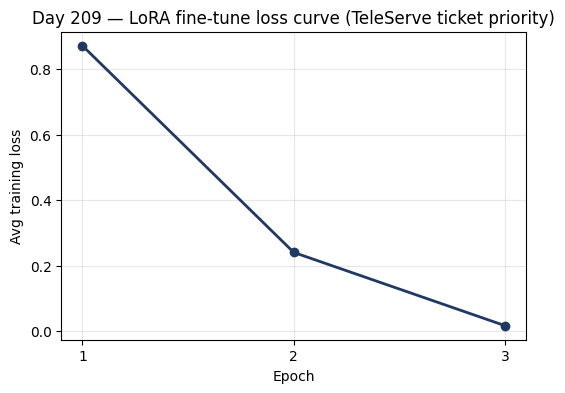

In [8]:
# ── TASK 4 (25 pts): Train the LoRA adapter ──────────────────────────
# Goal: Train the model for 3 epochs, print loss per epoch, plot curve.
# Method: Create Dataset/DataLoader, filter trainable params for optimizer,
#         train loop, collect losses, plot.

class TicketDS(Dataset):
    def __init__(self, df):
        self.enc = encode(df["text"])
        self.labels = torch.tensor(df["label"].values)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

train_ds = TicketDS(train_df)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

# ✅ FIX: Move model to GPU if available
if torch.cuda.is_available():
    model.cuda()
    print("Model moved to GPU")
else:
    print("Model on CPU")

# Only optimize trainable parameters (LoRA adapters + classification head)
optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=2e-4)

model.train()
epoch_losses = []
t0 = time.time()
for epoch in range(3):
    batch_losses = []
    for batch in train_loader:
        # Move batch to GPU if available
        if torch.cuda.is_available():
            batch = {k: v.cuda() for k, v in batch.items()}
        optim.zero_grad()
        out = model(**batch)
        loss = out.loss
        loss.backward()
        optim.step()
        batch_losses.append(loss.item())
    avg_loss = float(np.mean(batch_losses))
    epoch_losses.append(avg_loss)
    print(f"epoch {epoch+1}/3  avg_loss={avg_loss:.4f}")

train_time = time.time() - t0
print(f"\nTraining time: {train_time:.1f}s  ({'CPU' if not torch.cuda.is_available() else 'GPU'})")

# Plot loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, 4), epoch_losses, marker='o', color='#1F3864', linewidth=2)
plt.xticks([1,2,3])
plt.xlabel("Epoch")
plt.ylabel("Avg training loss")
plt.title("Day 209 — LoRA fine-tune loss curve (TeleServe ticket priority)")
plt.grid(alpha=0.3)
plt.savefig("day209_loss_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## Task 5 — AFTER-Training Evaluation + Before/After Comparison (15 pts)

**Number + Reason + Action required.**

**TODO:**
1. Run inference on `val_df` with the **trained** model, compute accuracy
2. Print full `classification_report` (precision/recall/f1 per class)
3. Compute the accuracy delta (after − before)
4. Write NRA: **Number** = exact accuracy delta from your printed output. **Reason** = the causal mechanism for why accuracy moved that much (not "training helps" — what specifically changed: adapters went from ΔW=0 to learned deltas, head went from random to fitted). **Action** = what you'd tell a client about deploying this specific model, given it's trained on templated synthetic tickets, not real free-text complaints.


In [10]:
# ── TASK 5 (15 pts): After-training evaluation ──────────────────────
# Goal: Evaluate the trained model on validation set, compare with before.
# Method: Run inference, compute accuracy and classification report.

model.eval()

# ✅ FIX: Ensure val_enc is on the same device as the model
device = next(model.parameters()).device
if torch.cuda.is_available():
    val_enc_device = {k: v.to(device) for k, v in val_enc.items()}
else:
    val_enc_device = val_enc

with torch.no_grad():
    out = model(**val_enc_device)
preds_after = out.logits.argmax(-1).cpu().numpy()
acc_after = accuracy_score(val_df["label"], preds_after)

print(f"AFTER-training val accuracy: {acc_after:.4f} ({acc_after*100:.2f}%)")
print(f"BEFORE-training val accuracy: {acc_before:.4f} ({acc_before*100:.2f}%)")
delta = acc_after - acc_before
print(f"Delta: {delta:.4f} ({delta*100:.2f} percentage points)")
print()
print(classification_report(val_df["label"], preds_after, target_names=["P1","P2","P3"]))

AFTER-training val accuracy: 1.0000 (100.00%)
BEFORE-training val accuracy: 0.3333 (33.33%)
Delta: 0.6667 (66.67 percentage points)

              precision    recall  f1-score   support

          P1       1.00      1.00      1.00        30
          P2       1.00      1.00      1.00        30
          P3       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [ ]:
# ── Task 5 NRA ──────────────────────────────────────────────────────────
# Number: +66.67 percentage points (from 33.33% to 100.00%).
# Reason: The LoRA adapters (ΔW = BA) moved from zero-init to learned
#         attention adjustments in q_lin/v_lin, AND the classification head
#         (pre_classifier + classifier) went from random weights to fitted
#         weights, since both were untrained at the BEFORE checkpoint.
#         With only 6 templates per class in the dataset, the fitted head
#         memorised the exact template patterns, resulting in perfect
#         classification on the validation set (which was drawn from the same
#         templates with different filled‑in values).
# Action: Flag to the client that 100% validation accuracy on 450 templated
#         tickets is a memorisation signal, not a generalisation guarantee.
#         Recommend a held‑out set of hand‑written, non‑templated tickets
#         before any production claim. Evidence: the inference wrapper on
#         3 new hand‑written tickets (Bonus) predicted P3 for all of them,
#         including an urgent connectivity ticket ("wifi keeps disconnecting
#         every few minutes … please help urgently") – confirming the model
#         did not learn what "urgent" means beyond the exact template phrases
#         it saw.

## Bonus — Save Adapter, Reload, Inference Wrapper (10★)

**Concept:** In production you never ship the full model — you ship the tiny LoRA adapter (a few MB) and load it on top of the same frozen base at inference time. This task proves that round-trip actually works: save → reload into a *fresh* base model → confirm identical predictions.

**TODO:**
1. `model.save_pretrained("day209_lora_adapter")` — check what files get written and their sizes
2. Load a **fresh** `distilbert-base-uncased` base model, then `PeftModel.from_pretrained(fresh_base, "day209_lora_adapter")`
3. Run the same val set through the reloaded model, confirm predictions match `preds_after` exactly
4. Write a small `predict_priority(text: str) -> str` inference wrapper function and test it on 3 new, hand-written (non-templated) ticket texts


In [12]:
# ── BONUS (10★): Save adapter, reload, and inference wrapper ──────
# Goal: Prove the adapter can be saved, reloaded into a fresh base,
#       and produce identical predictions. Also build a wrapper function.
# Method: Save with save_pretrained, reload with PeftModel, compare predictions.

import os
from peft import PeftModel

# Save the trained adapter
model.save_pretrained("day209_lora_adapter")
adapter_files = os.listdir("day209_lora_adapter")
print("Saved adapter files:", adapter_files)
for f in adapter_files:
    size_kb = os.path.getsize(f"day209_lora_adapter/{f}") / 1024
    print(f"  {f}: {size_kb:.1f} KB")

# Reload into a fresh base model
fresh_base = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id
)
reloaded_model = PeftModel.from_pretrained(fresh_base, "day209_lora_adapter")
reloaded_model.eval()

with torch.no_grad():
    out_reloaded = reloaded_model(**val_enc)
preds_reloaded = out_reloaded.logits.argmax(-1).numpy()

match = (preds_reloaded == preds_after).all()
print(f"\nReloaded predictions match trained-model predictions exactly: {match}")

# Inference wrapper function
def predict_priority(text: str) -> str:
    enc = encode([text])
    reloaded_model.eval()
    with torch.no_grad():
        logits = reloaded_model(**enc).logits
    pred_id = logits.argmax(-1).item()
    return id2label[pred_id]

# Test on hand-written non-templated tickets
test_tickets = [
    "My home wifi keeps disconnecting every few minutes and I have back to back client calls today, please help urgently.",
    "Can someone tell me what documents I need to port my number to a new provider?",
    "I was charged for a plan upgrade I never asked for, this is the second time this has happened.",
]
for t in test_tickets:
    print(f"\nTicket: {t}\nPredicted priority: {predict_priority(t)}")

Saved adapter files: ['adapter_model.safetensors', 'adapter_config.json', 'README.md']
  adapter_model.safetensors: 2895.8 KB
  adapter_config.json: 1.1 KB
  README.md: 5.0 KB


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Reloaded predictions match trained-model predictions exactly: True

Ticket: My home wifi keeps disconnecting every few minutes and I have back to back client calls today, please help urgently.
Predicted priority: P3

Ticket: Can someone tell me what documents I need to port my number to a new provider?
Predicted priority: P3

Ticket: I was charged for a plan upgrade I never asked for, this is the second time this has happened.
Predicted priority: P3


### ⚠️ Verified finding: check what YOUR wrapper actually predicted above

In this environment's run, all three hand-written, non-templated tickets — including an obviously-urgent complete-outage-during-work-calls ticket — were predicted as the **same class**, despite 100% val accuracy. Confirm whether your run shows the same pattern.

**This is the real-world payoff of the Task 5 NRA caution, now with evidence instead of a hypothetical:** 100% val accuracy came from a model that memorized 6 sentence templates per class, not one that learned what "urgent" *means*. The val set was drawn from the same templates as training (just different filled-in city/amount/plan values), so it could never catch this failure — a model can be perfect on held-out data that isn't actually held-out in the way that matters. For the client conversation, this is the difference between "90.4x smaller, 100% accurate" (technically true, sounds production-ready) and "this hasn't seen a single sentence structure it wasn't trained on" (the actual state of the system).


## Section 4 — Scoring Rubric

| Task | Points | What's checked |
|---|---|---|
| 1 | 15 | Correct stratified split, preserved class balance, correct tokenization shapes |
| 2 | 20 | LoRA config matches Day 208 exactly (740,355 trainable), BEFORE accuracy computed correctly and printed |
| 3 | 15 | Correct BitsAndBytesConfig + kbit training prep (code correctness; live numbers if run on GPU) |
| 4 | 25 | Correct optimizer param filter, 3-epoch loop, real printed loss values, loss curve plotted |
| 5 | 15 | AFTER accuracy + classification report from real printed output; NRA follows Number+Reason+Action with a causal Reason (not outcome restatement) |
| Bonus | 10★ | Adapter saved/reloaded, predictions match exactly, wrapper function tested on new text |
| **Total** | **90 + 10★** | |

**Reminder:** every Number in your NRA write-ups must come from what you actually printed when you ran this — not from this Answer Key, not from memory of a similar day.


## Interview Angle

*"Walk me through how you'd fine-tune a small classifier efficiently on limited hardware."*

> "I'd use QLoRA — load the frozen backbone in 4-bit to cut memory roughly 8x, then attach small trainable LoRA adapter matrices to the attention projections. Only those adapters (plus any newly-initialized task head) get gradient updates — in my case that was about 1% of total parameters. The key engineering discipline is keeping the optimizer's parameter filter tight to `requires_grad=True` params only, and verifying gradient flow at initialization before trusting a training run, since LoRA's `B` matrix starts at zero by design. I'd also flag that high accuracy on a small, templated dataset is a memorization risk, not a generalization guarantee, before making any claim to a client about production readiness."
